In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df=pd.read_csv('/content/drive/MyDrive/Social_Network_Ads.csv')

In [8]:
df.drop(columns=['Gender','User ID'],inplace=True)

In [9]:
df.sample(5)

,Age,EstimatedSalary,Purchased
305,42,54000,0
235,46,79000,1
300,58,38000,1
262,55,125000,1
169,29,47000,0


### **Train Test Split**

It is recommended

train_test_split=(features,output or target,test size,random_splitting of data)

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(
    df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0
)

X_train.shape,X_test.shape

((280, 2), (120, 2))

### **Standard Scaler**

Your model learn only from training data but you transform both training and testing data

In [15]:
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()

# fit the scaler to train and test sets
Scaler.fit(X_train)

X_train_Scaled=Scaler.transform(X_train)
X_test_Scaled=Scaler.transform(X_test)

In [16]:
Scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

To convert numpy array returned from X_train_scaled to DataFrame of pandas

In [18]:
X_train_Scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

### **columns=X_train.columns**

Ye original training DataFrame ke column names le raha hai.

In [20]:
X_train_Scaled=pd.DataFrame(X_train_Scaled,columns=X_train.columns)
X_test_Scaled=pd.DataFrame(X_test_Scaled,columns=X_test.columns)

In [22]:
X_train_Scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [23]:
X_train.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.864286,69807.142857
std,10.218201,34641.201654
min,18.000000,15000.000000
25%,30.000000,43000.000000
50%,37.000000,70500.000000
75%,46.000000,88000.000000
max,60.000000,150000.000000


Mean and Standard Deviation of Original DataSet

In [21]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


Mean and Standard Deviation of Scaled Data

In [24]:
np.round(X_train_Scaled.describe(),1)
# mean turned to 0 (mean centering)
# standard deviation turned to 1 after scaling

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


### **Effects of Scaling**

No difference in distance....except the point that origin has shifted now and came on minimum values

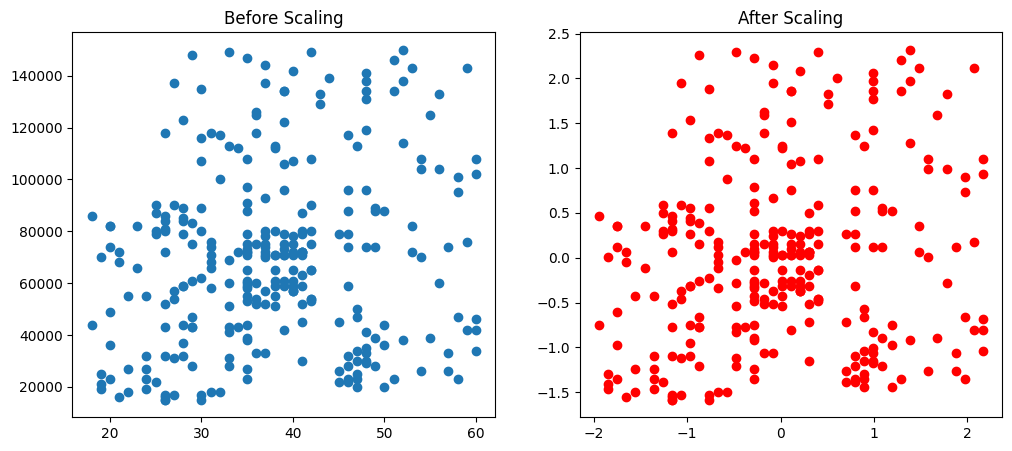

In [30]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
# After Scaling
ax2.scatter(X_train_Scaled['Age'],X_train_Scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")

plt.show()


To see the actual benefit of Scaling

### **Plot PDF**

Probability Density Function

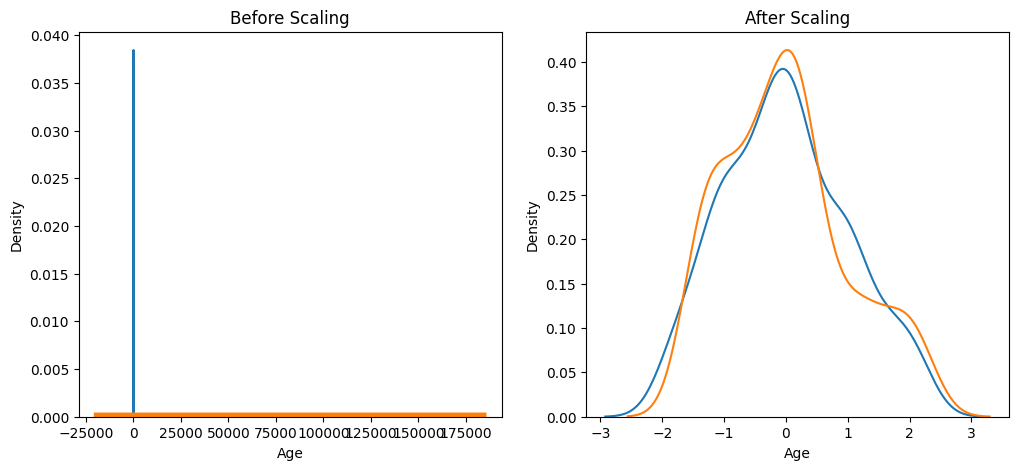

In [35]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1,linewidth=6)

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_Scaled['Age'],ax=ax2)
sns.kdeplot(X_train_Scaled['EstimatedSalary'],ax=ax2)

plt.show()

### **Comparison of Distribution**

Individual Comparison

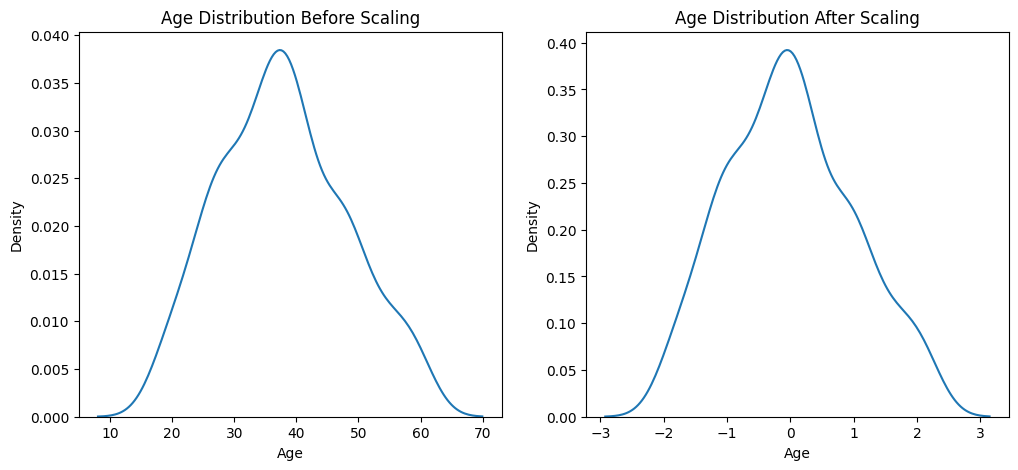

In [36]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

# Age Distribution Before Scaling
ax1.set_title("Age Distribution Before Scaling")
sns.kdeplot(X_train['Age'],ax=ax1)

# Age Distribution After Scaling
ax2.set_title("Age Distribution After Scaling")
sns.kdeplot(X_train_Scaled['Age'],ax=ax2)


plt.show()

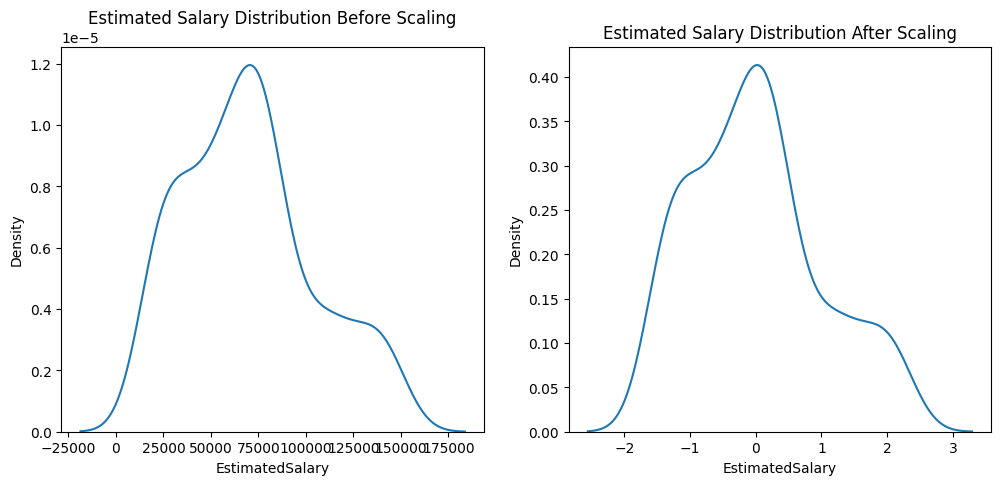

In [38]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

# Salary Distribution Before Scaling
ax1.set_title("Estimated Salary Distribution Before Scaling")
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

# Salary Distribution After Scaling
ax2.set_title("Estimated Salary Distribution After Scaling")
sns.kdeplot(X_train_Scaled['EstimatedSalary'],ax=ax2)


plt.show()

### **Why Scaling is Important ?**


### **Logistic Regression**

In [39]:
from sklearn.linear_model import LogisticRegression


In [40]:
# logistic regression without scaling values
lr=LogisticRegression()
# logistic regression with scaled values
lr_scaled=LogisticRegression()

In [42]:
lr.fit(X_train,Y_train)
lr_scaled.fit(X_train_Scaled,Y_train)

LogisticRegression()

In [43]:
y_pred=lr.predict(X_test)
y_pred_Scaled=lr_scaled.predict(X_test_Scaled)

Now let's see accuracy score

In [44]:
from sklearn.metrics import accuracy_score

In [47]:
print("Actual ",accuracy_score(Y_test,y_pred))
print("Scaled ",accuracy_score(Y_test,y_pred_Scaled))

Actual  0.875
Scaled  0.8666666666666667


### **Decision Tree**

Let see accuracy over Descision Tree Algorithm

Decision Tree isn't affected by Scaling so much as much as Logistic Regression is affected

In [49]:
from sklearn.tree import DecisionTreeClassifier

In [50]:
dt=DecisionTreeClassifier()
dt_scaled=DecisionTreeClassifier()

In [51]:
dt.fit(X_train,Y_train)
dt_scaled.fit(X_train_Scaled,Y_train)

DecisionTreeClassifier()

In [52]:
y_pred=dt.predict(X_test)
y_pred_Scaled=dt_scaled.predict(X_test_Scaled)

In [53]:
from sklearn.metrics import accuracy_score

In [54]:
print("Actual ",accuracy_score(Y_test,y_pred))
print("Scaled ",accuracy_score(Y_test,y_pred_Scaled))

Actual  0.875
Scaled  0.875


### **Outlier Detection**

In [55]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


### **Let's add Outlier to Data**

In [58]:
df = pd.concat([
    df,
    pd.DataFrame({
        'Age': [5, 90, 95],
        'EstimatedSalary': [1000, 250000, 350000],
        'Purchase': [0, 1, 1]
    })
], ignore_index=True)

In [59]:
df

,Age,EstimatedSalary,Purchased,Purchase
0,19,19000,0.0,NaN
1,35,20000,0.0,NaN
2,26,43000,0.0,NaN
3,27,57000,0.0,NaN
4,19,76000,0.0,NaN
...,...,...,...,...
398,36,33000,0.0,NaN
399,49,36000,1.0,NaN
400,5,1000,NaN,0.0
401,90,250000,NaN,1.0


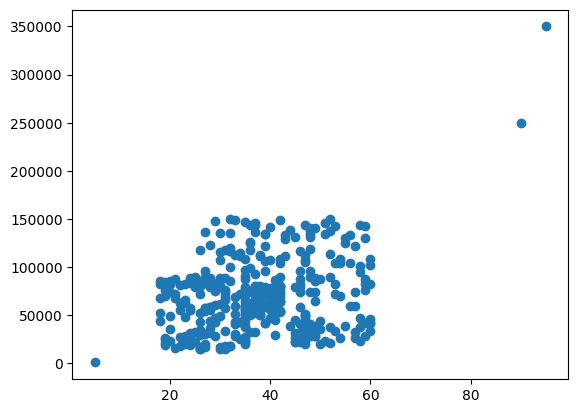

In [60]:
plt.scatter(df['Age'],df['EstimatedSalary'])
plt.show()

In [63]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)


In [64]:
X_train.shape,X_test.shape

((282, 3), (121, 3))

In [67]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

scaler.fit(X_train)

# transformation
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [68]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

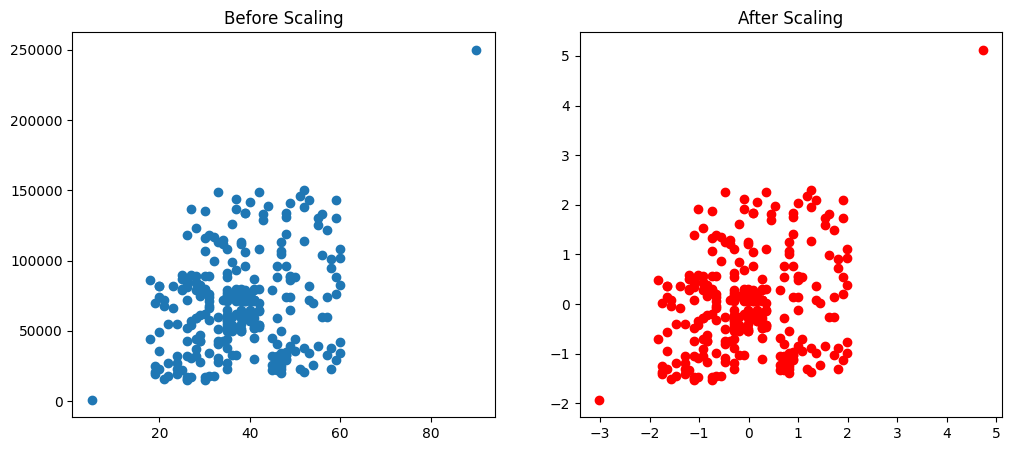

In [69]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
# After Scaling
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")

plt.show()
